### data handling and create model for pelagic fish data

In [2]:
import pandas as pd
import numpy as np
pelagic_train_df = pd.read_csv('D:/program/aquatic/data/pelagic_training_set.csv')

In [4]:
pelagic_train_df['Habitat_Type'].unique()

<ArrowStringArray>
['Marine']
Length: 1, dtype: str

In [2]:
#convert string to numbers
from sklearn.preprocessing import OrdinalEncoder
ordinal_encod = OrdinalEncoder()
string_cols = pelagic_train_df.select_dtypes(include=['string','object']).columns
pelagic_train_df[string_cols] = ordinal_encod.fit_transform(pelagic_train_df[string_cols])

In [3]:
#train the model using best hyperparameter, chosen for ecological study
pelagic_labels = pelagic_train_df['Estimated_Age_yr']
pelagic_train_df = pelagic_train_df.drop(columns=['Estimated_Age_yr'])
from sklearn.ensemble import RandomForestRegressor
randomforest = RandomForestRegressor(random_state=42)
#fine tune model using grid search
from sklearn.model_selection import GridSearchCV
param_dist = {
    'n_estimators': [200,500,1000],
    'max_features': [3, 5, 7], 
    'min_samples_leaf': [5,20],
    'max_depth': [10, 20, None],
}#parameters useful in ecology setting
grid_search = GridSearchCV(randomforest, param_dist, cv=3, 
                           scoring='neg_root_mean_squared_error',n_jobs=-1, verbose=1)
grid_searched_model = grid_search.fit(pelagic_train_df, pelagic_labels)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


In [4]:
#evaluate the result using cross valuation with rmse
from sklearn.model_selection import cross_val_score
forest_rmse = -cross_val_score(grid_searched_model, pelagic_train_df, pelagic_labels, 
                              scoring='neg_root_mean_squared_error',n_jobs=-1, verbose=1,cv=10)
pd.Series(forest_rmse).describe()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed: 21.0min finished


count    10.000000
mean      2.917087
std       0.094433
min       2.736012
25%       2.877971
50%       2.939050
75%       2.989630
max       3.007996
dtype: float64

In [5]:
#handle test_set data
test_set = pd.read_csv('D:/program/aquatic/data/pelagic_test_set.csv')
string_cols = test_set.select_dtypes(include=['object','str']).columns
test_set[string_cols] = ordinal_encod.fit_transform(test_set[string_cols])

In [ ]:
#evaluate on test set
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
final_model = grid_searched_model.best_estimator_
X_test = test_set.drop('Estimated_Age_yr', axis=1)
y_test = test_set['Estimated_Age_yr'].copy()

final_prediction = final_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test,final_prediction))
test_mae = mean_absolute_error(y_test, final_prediction)
test_r2 = r2_score(y_test, final_prediction)

print(f'Test RMSE: {test_rmse:.3f} years')
print(f'Test MAE: {test_mae:.3f} years')
print(f'Test R²: {test_r2:.3f}')
#not bad, off by <3yrs

Test RMSE: 2.903 years
Test MAE: 1.984 years
Test R²: 0.744


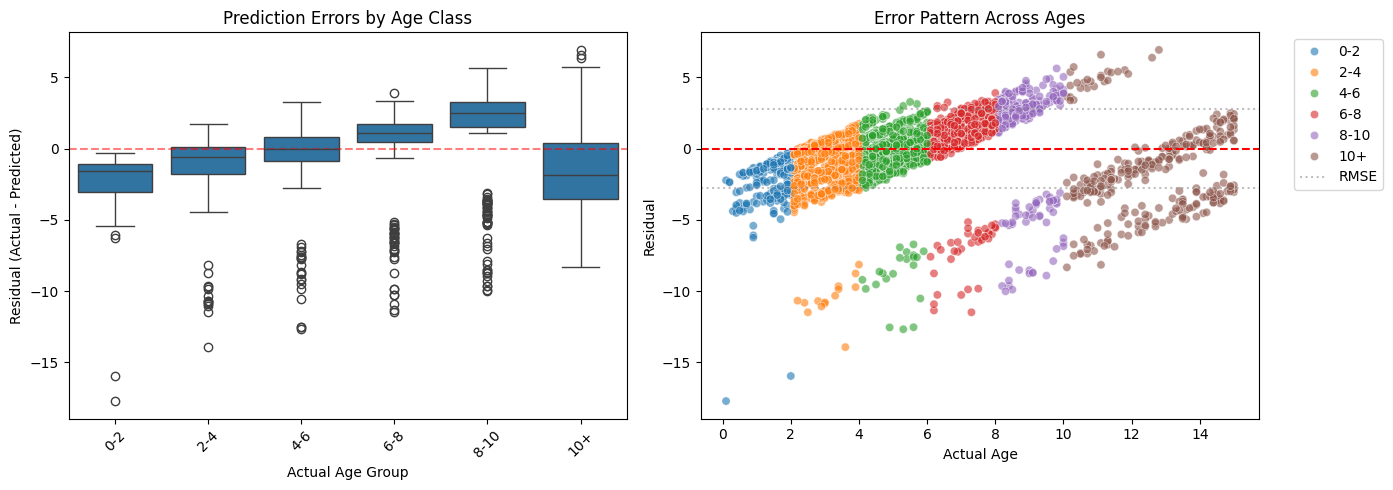


RMSE by Age Group:
Age_Group
0-2     2.806671
2-4     1.951344
4-6     1.846005
6-8     2.377462
8-10    3.891720
10+     3.432379
dtype: float64


In [7]:
#visualize the error
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get predictions and residuals
residuals = y_test - final_prediction

# Create age groups
age_groups = pd.cut(y_test, bins=[0, 2, 4, 6, 8, 10, 15], 
                    labels=['0-2', '2-4', '4-6', '6-8', '8-10', '10+'])

df_errors = pd.DataFrame({
    'Actual_Age': y_test,
    'Predicted_Age': final_prediction,
    'Residual': residuals,
    'Age_Group': age_groups
})

# Plot 1: Error by age group
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Age_Group', y='Residual', data=df_errors)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('Prediction Errors by Age Class')
plt.xlabel('Actual Age Group')
plt.ylabel('Residual (Actual - Predicted)')
plt.xticks(rotation=45)

# Plot 2: Where are the biggest errors?
plt.subplot(1, 2, 2)
sns.scatterplot(x='Actual_Age', y='Residual', data=df_errors, 
                hue='Age_Group', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.axhline(y=2.76, color='gray', linestyle=':', alpha=0.5, label='RMSE')
plt.axhline(y=-2.76, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Actual Age')
plt.ylabel('Residual')
plt.title('Error Pattern Across Ages')
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Calculate RMSE by age group
rmse_by_age = df_errors.groupby('Age_Group').apply(
    lambda x: np.sqrt(np.mean(x['Residual']**2))
)
print("\nRMSE by Age Group:")
print(rmse_by_age)

#for young age (0-2), old age(8-10), errors seems to be more significant

In [8]:
import joblib
joblib.dump(final_model, 'D:/program/aquatic/scripts/fish_age_model.pkl')


['D:/program/aquatic/scripts/fish_age_model.pkl']